# Business Understanding

## Project Domain

**teks Healthcare Predictive Analytics tebal**
Proyek ini berada dalam domain kesehatan dan prediksi penyakit dengan memanfaatkan data klinis pasien untuk membantu diagnosis awal penyakit liver (hati) menggunakan teknologi machine learning, khususnya Artificial Neural Network (ANN).

## Problem Statements

Banyak kasus penyakit liver yang baru terdeteksi saat sudah dalam kondisi kronis karena kurangnya diagnosis dini. Dokter sering kali membutuhkan waktu dan pemeriksaan lanjutan untuk memutuskan apakah seseorang mengidap penyakit liver atau tidak. Hal ini menimbulkan tantangan dalam:

Mendeteksi pasien liver secara cepat dan akurat.

Mengurangi beban pemeriksaan laboratorium yang mahal dan memakan waktu.

## Goals

Tujuan utama dari proyek ini adalah:

Mengembangkan model prediksi berbasis Artificial Neural Network (ANN) untuk mengidentifikasi apakah seorang pasien kemungkinan mengidap penyakit liver berdasarkan data klinis dasar.

Memberikan alat bantu diagnosis berbentuk aplikasi interaktif (Streamlit) yang bisa digunakan oleh tenaga kesehatan untuk pengambilan keputusan awal.

Memastikan model memiliki akurasi minimal 80% dan dapat digunakan dengan antarmuka yang sederhana dan portable.



## Solution Statements

Proyek ini menawarkan solusi berupa:

Pembuatan model Artificial Neural Network dengan pelatihan data pasien liver dari dataset ILPD.

Proses data preprocessing, normalisasi, dan penyandian fitur kategorikal agar data siap digunakan untuk model.

Evaluasi model dengan metrik seperti akurasi dan confusion matrix untuk memastikan keandalan.

Deploy model dalam bentuk aplikasi Streamlit dan ekspor ke format TFLite untuk digunakan di perangkat ringan, serta menyimpan preprocessing tools sebagai file .pkl.

# Data Understanding

## Import data dari kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"edwinfajarr","key":"c6d321ac59ac3879408e08cd3eccdac1"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d fatemehmehrparvar/liver-disorders

Dataset URL: https://www.kaggle.com/datasets/fatemehmehrparvar/liver-disorders
License(s): Attribution 4.0 International (CC BY 4.0)


In [4]:
!mkdir liver-disorders
!unzip liver-disorders -d liver-disorders
!ls liver-disorders

Archive:  liver-disorders.zip
  inflating: liver-disorders/Indian Liver Patient Dataset (ILPD).csv  
'Indian Liver Patient Dataset (ILPD).csv'


## Import Library yang dibutuhkan

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import pickle

## Exploratory Data Analysis

In [6]:
df = pd.read_csv('/content/liver-disorders.zip')

In [7]:
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [9]:
print(df.columns)

Index(['Age', 'Gender', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB',
       'A/G Ratio', 'Selector'],
      dtype='object')


In [11]:
if "A/G Ratio" in df.columns:
    df["A/G Ratio"] = df["A/G Ratio"].fillna(df["A/G Ratio"].median())

In [14]:
if "Gender" in df.columns:
    df["Gender"] = df["Gender"].map({"Male": "Laki-Laki", "Female": "Perempuan"})

if "Selector" in df.columns:
    df["Status"] = df["Selector"].map({1: "Liver", 2: "Non-Liver"})

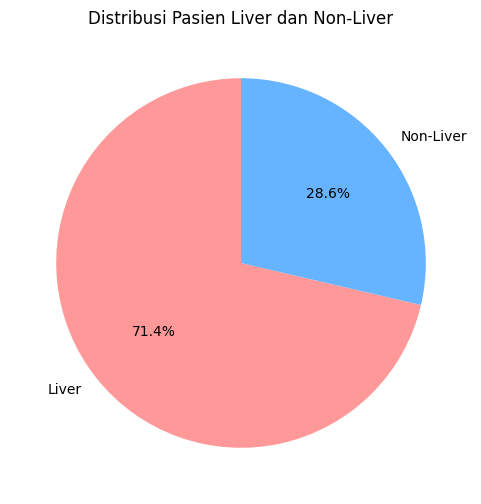

In [15]:
if "Status" in df.columns:
    plt.figure(figsize=(6, 6))
    df["Status"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, colors=["#ff9999", "#66b3ff"])
    plt.title("Distribusi Pasien Liver dan Non-Liver")
    plt.ylabel("")
    plt.show()

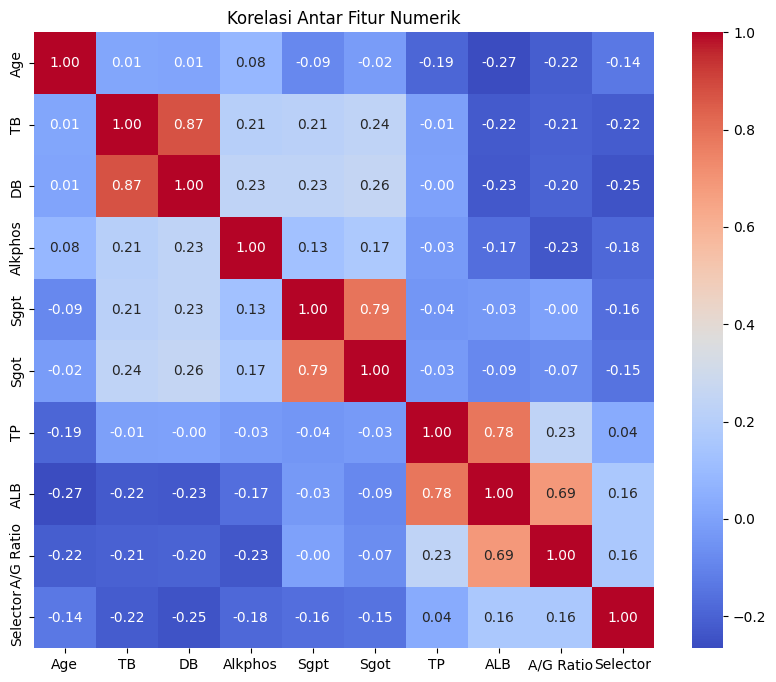

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=["float64", "int64"]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Antar Fitur Numerik")
plt.show()

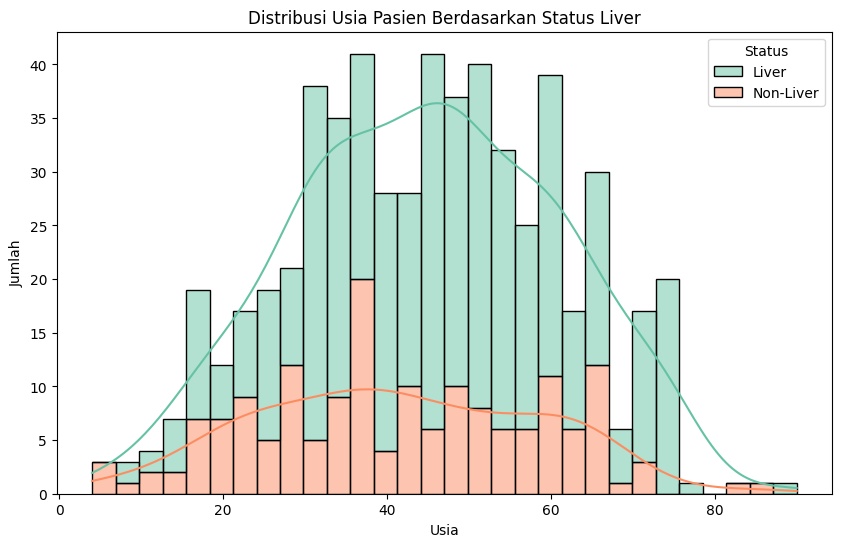

In [17]:
if "Age" in df.columns and "Status" in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x="Age", hue="Status", kde=True, multiple="stack", palette="Set2", bins=30)
    plt.title("Distribusi Usia Pasien Berdasarkan Status Liver")
    plt.xlabel("Usia")
    plt.ylabel("Jumlah")
    plt.show()

<ipython-input-18-b8170dfc71e1>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Gender", y="TP", palette="pastel")


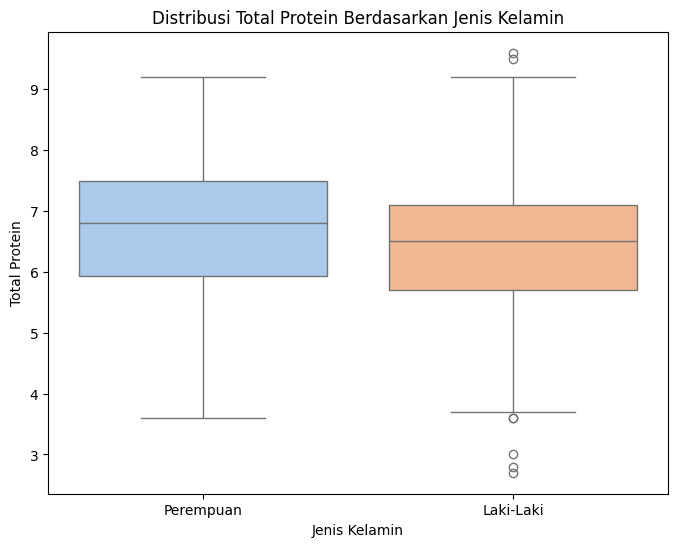

In [18]:
if "TP" in df.columns and "Gender" in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x="Gender", y="TP", palette="pastel")
    plt.title("Distribusi Total Protein Berdasarkan Jenis Kelamin")
    plt.xlabel("Jenis Kelamin")
    plt.ylabel("Total Protein")
    plt.show()

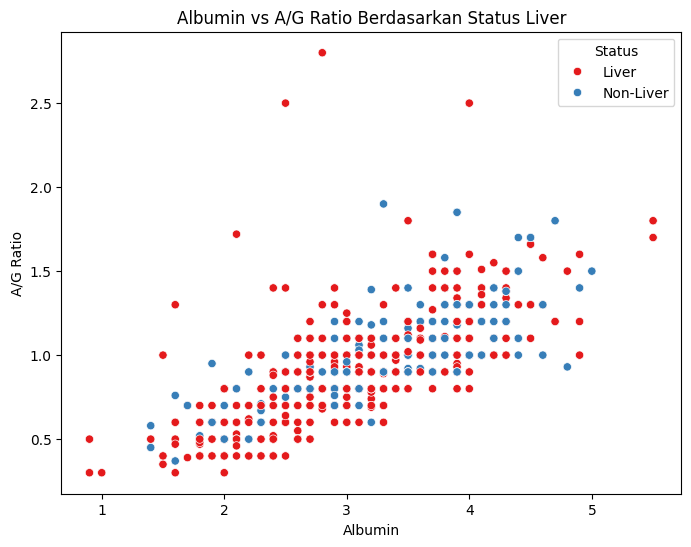

In [19]:
if "ALB" in df.columns and "A/G Ratio" in df.columns and "Status" in df.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x="ALB", y="A/G Ratio", hue="Status", palette="Set1")
    plt.title("Albumin vs A/G Ratio Berdasarkan Status Liver")
    plt.xlabel("Albumin")
    plt.ylabel("A/G Ratio")
    plt.show()

# Data Preparation

In [25]:
df_model = df.drop(columns=["Status"])

In [21]:
df_model["A/G Ratio"] = SimpleImputer(strategy="median").fit_transform(df_model[["A/G Ratio"]])

In [26]:
le_gender = LabelEncoder()
df_model["Gender"] = le_gender.fit_transform(df_model["Gender"])

In [27]:
X = df_model.drop(columns=["Selector"])
y = df_model["Selector"] - 1

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# Modeling

In [30]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

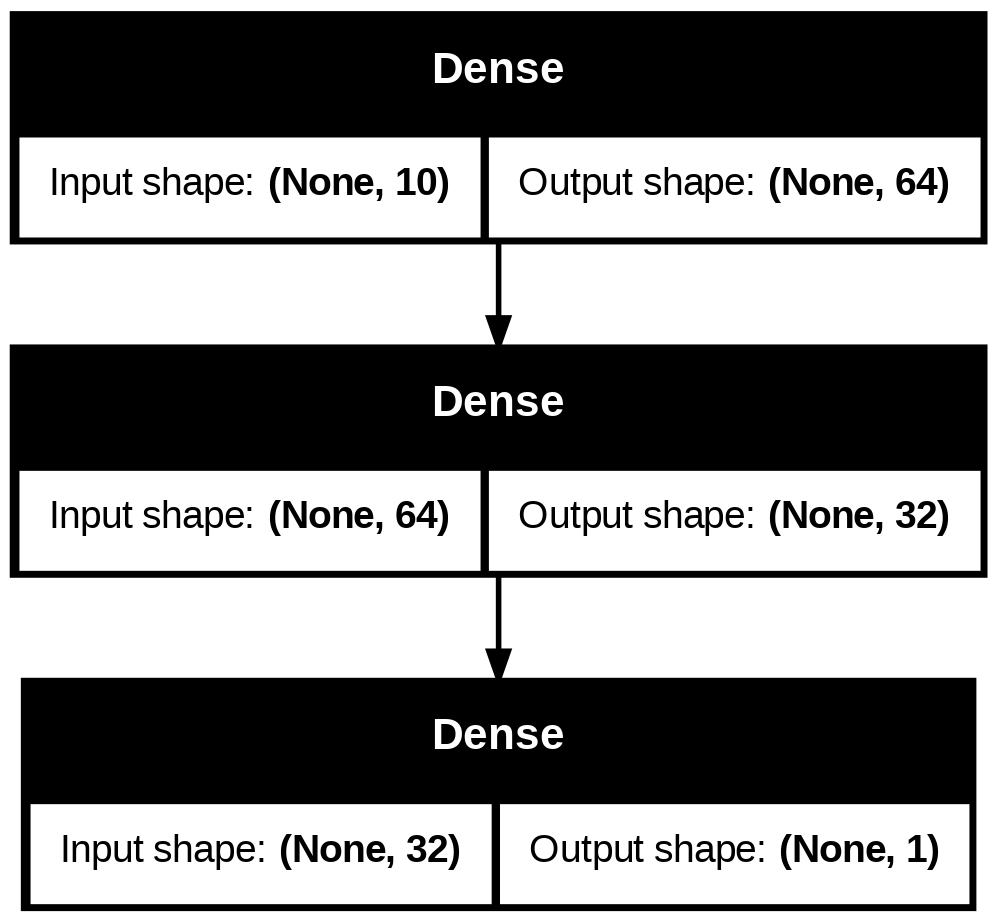

In [33]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [34]:
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6396 - loss: 0.6503 - val_accuracy: 0.7436 - val_loss: 0.5480
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6900 - loss: 0.5732 - val_accuracy: 0.7436 - val_loss: 0.5153
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7257 - loss: 0.5271 - val_accuracy: 0.7436 - val_loss: 0.5029
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6804 - loss: 0.5366 - val_accuracy: 0.7436 - val_loss: 0.4949
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7204 - loss: 0.5060 - val_accuracy: 0.7436 - val_loss: 0.4861
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7039 - loss: 0.5194 - val_accuracy: 0.7607 - val_loss: 0.4781
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7334 - loss: 0.5002 - val_accuracy: 0.7863 - val_loss: 0.4742
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7557 - loss: 0.5044 - val_accuracy: 0.7778 - val_loss

# Evaluation

In [35]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nAkurasi: {accuracy * 100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8162 - loss: 0.4184

Akurasi: 80.34%


In [36]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87        87
           1       0.65      0.50      0.57        30

    accuracy                           0.80       117
   macro avg       0.75      0.70      0.72       117
weighted avg       0.79      0.80      0.79       117



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


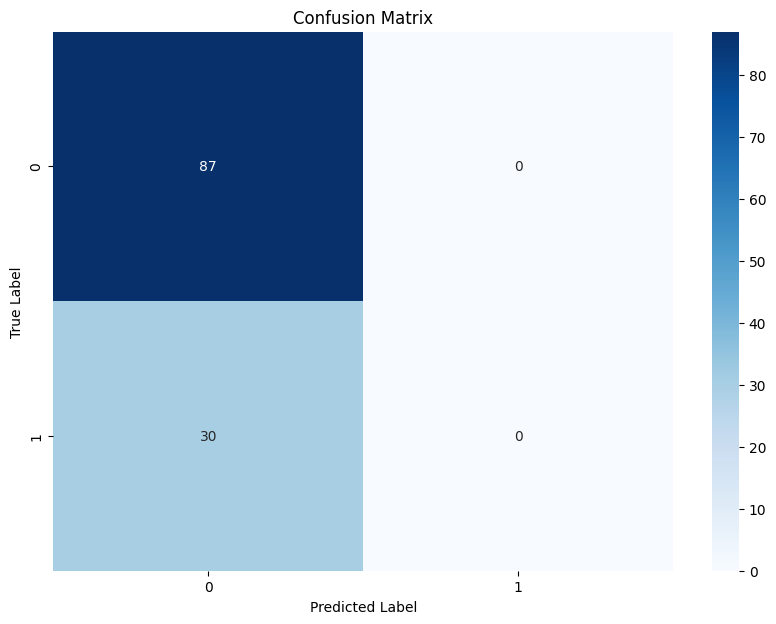

Classification Report:
              precision    recall  f1-score   support

           0       0.74      1.00      0.85        87
           1       0.00      0.00      0.00        30

    accuracy                           0.74       117
   macro avg       0.37      0.50      0.43       117
weighted avg       0.55      0.74      0.63       117



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [40]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("model_liver.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp9izo5pax'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139072484175952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139072484177104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139072484175376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139072484171728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139072484177680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139072484173840: TensorSpec(shape=(), dtype=tf.resource, name=None)


## Save Model

In [41]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le_gender, f)